# Optimizing the Training Process — Avoiding Underfitting and Overfitting
## 1. Introduction

### Objectives
- Understand what underfitting and overfitting mean.
- Learn how to detect them using training/testing data.
- Explore the model complexity graph.
- Understand regularization (L1, L2) as a remedy for overfitting.


## 2. Concept: Underfitting vs. Overfitting

Underfitting = Model too simple → fails to capture data trends.  
Overfitting = Model too complex → memorizes noise instead of learning.

**Analogy:**  
- Underfitting = Not studying enough for an exam.  
- Overfitting = Memorizing the entire book instead of learning concepts.  
- Good model = Studying effectively — generalizing to unseen questions.


**Visualization Example**:

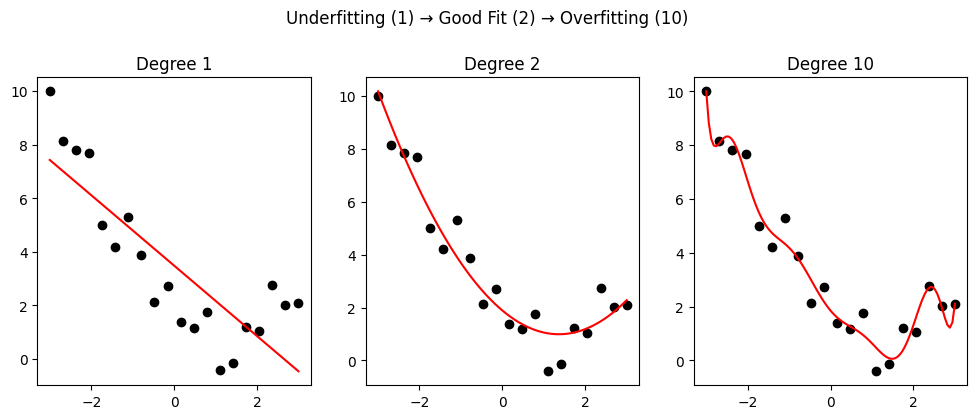

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create data
np.random.seed(42)
X = np.linspace(-3, 3, 20)
y = 0.5 * X**2 - X + 2 + np.random.randn(20)

# Fit models
degrees = [1, 2, 10]
plt.figure(figsize=(12,4))
for i, d in enumerate(degrees):
    poly = PolynomialFeatures(d)
    X_poly = poly.fit_transform(X.reshape(-1,1))
    model = LinearRegression().fit(X_poly, y)
    X_test = np.linspace(-3,3,100)
    y_pred = model.predict(poly.transform(X_test.reshape(-1,1)))

    plt.subplot(1,3,i+1)
    plt.scatter(X, y, color='black')
    plt.plot(X_test, y_pred, color='red')
    plt.title(f'Degree {d}')
plt.suptitle("Underfitting (1) → Good Fit (2) → Overfitting (10)", y=1.05)
plt.show()


### Testing and Validation:

**Why Testing?**
To detect overfitting, we split the data:
- **Training Set:** Used to fit the model.
- **Testing Set:** Used only for final evaluation.

**The golden rule:** never use your testing data for training or tuning your model

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1,1), y, test_size=0.2, random_state=42)


### Model Complexity Graph

Show the tradeoff between training and validation errors:

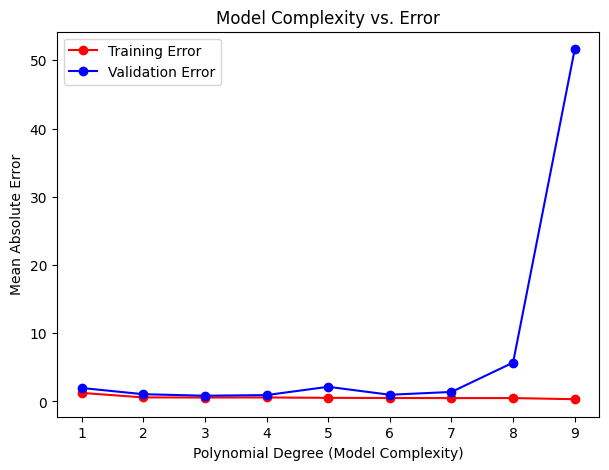

In [3]:
from sklearn.metrics import mean_absolute_error
train_err, val_err = [], []
degrees = range(1,10)
for d in degrees:
    poly = PolynomialFeatures(d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression().fit(X_train_poly, y_train)
    train_err.append(mean_absolute_error(y_train, model.predict(X_train_poly)))
    val_err.append(mean_absolute_error(y_test, model.predict(X_test_poly)))

plt.figure(figsize=(7,5))
plt.plot(degrees, train_err, 'r-o', label='Training Error')
plt.plot(degrees, val_err, 'b-o', label='Validation Error')
plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.title("Model Complexity vs. Error")
plt.show()


## 3. Regularization — Balancing Performance and Simplicity

Regularization adds a *complexity penalty* to discourage overly large weights.

**Objective:**  
$
\text{Error} = \text{Loss} + \lambda \times \text{Complexity}
$

- **L1 (Lasso):** forces some coefficients → 0 (feature selection).  
- **L2 (Ridge):** shrinks coefficients but keeps all (stability).


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.597e+00, tolerance: 1.661e-02
  model = cd_fast.enet_coordinate_descent(


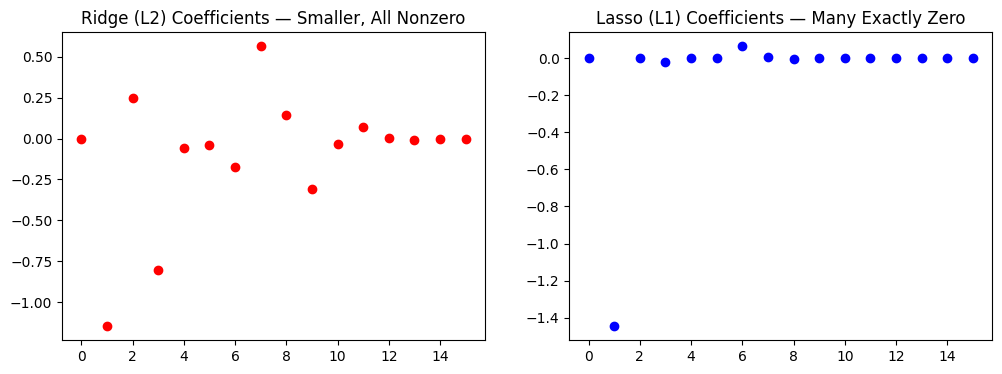

In [4]:
from sklearn.linear_model import Ridge, Lasso
poly = PolynomialFeatures(15)
X_poly = poly.fit_transform(X.reshape(-1,1))

ridge = Ridge(alpha=1).fit(X_poly, y)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_poly, y)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ridge.coef_, 'ro')
plt.title("Ridge (L2) Coefficients — Smaller, All Nonzero")

plt.subplot(1,2,2)
plt.plot(lasso.coef_, 'bo')
plt.title("Lasso (L1) Coefficients — Many Exactly Zero")
plt.show()


## Exercise 4.1:

We trained four models with different hyperparameters and recorded their **training** and **testing** errors:

| Model | Train Error | Test Error |
|------:|------------:|-----------:|
| 1 | 0.1 | 1.8 |
| 2 | 0.4 | 1.2 |
| 3 | 0.6 | 0.8 |
| 4 | 1.9 | 2.3 |

**Tasks**
1. Select the best model for this dataset.  
2. Identify which model looks **underfitted**.  
3. Identify which model(s) look **overfitted**.


In [5]:
import pandas as pd
import numpy as np

# Data
df = pd.DataFrame({
    "model": [1, 2, 3, 4],
    "train_error": [0.1, 0.4, 0.6, 1.9],
    "test_error":  [1.8, 1.2, 0.8, 2.3],
})

df


,model,train_error,test_error
0,1,0.1,1.8
1,2,0.4,1.2
2,3,0.6,0.8
3,4,1.9,2.3


## Heuristics

- **Best model**: smallest **test error** (generalization performance).  
- **Underfitting**: both **train** and **test** errors are **high** (model too simple).  
- **Overfitting**: **train** error very **low** but **test** error relatively **high** (memorization).

To make this programmatic (and reusable), we’ll:
- Pick the **best** as `idxmin` of `test_error`.
- Flag **underfit** as the model maximizing `train_error + test_error` (penalizes models that do poorly in both).
- Flag **overfit** as models with `train_error` in the **lowest** quantile and `test_error` in the **highest** quantile.


In [6]:
# 1) Best model = argmin test_error
best_model_row = df.loc[df["test_error"].idxmin()]

# 2) Underfitting = high train & high test -> we use the largest sum as a simple proxy
underfit_row = df.loc[(df["train_error"] + df["test_error"]).idxmax()]

# 3) Overfitting = very low train & relatively high test
# Use quantiles to avoid hard-coded thresholds
low_train_thresh  = df["train_error"].quantile(0.35)  # lowest ~1-2 models
high_test_thresh  = df["test_error"].quantile(0.65)   # highest ~1-2 models

overfit_mask = (df["train_error"] <= low_train_thresh) & (df["test_error"] >= high_test_thresh)
overfit_rows = df.loc[overfit_mask].copy()

best_model_row, underfit_row, overfit_rows


(model          3.0
 train_error    0.6
 test_error     0.8
 Name: 2, dtype: float64,
 model          4.0
 train_error    1.9
 test_error     2.3
 Name: 3, dtype: float64,
    model  train_error  test_error
 0      1          0.1         1.8)

## Results


In [7]:
print("Best model (min test error):")
print(best_model_row.to_frame().T.to_string(index=False))

print("\nUnderfitting (high train + high test):")
print(underfit_row.to_frame().T.to_string(index=False))

print("\nOverfitting candidates (low train & high test):")
print(overfit_rows.to_string(index=False) if not overfit_rows.empty else "None")


Best model (min test error):
 model  train_error  test_error
   3.0          0.6         0.8

Underfitting (high train + high test):
 model  train_error  test_error
   4.0          1.9         2.3

Overfitting candidates (low train & high test):
 model  train_error  test_error
     1          0.1         1.8


## Plain-English Answers

**a) Which model would you select for this dataset?**  
- **Model 3** (test error = 0.8, the lowest) — it generalizes best.

**b) Which model looks like it’s underfitting the data?**  
- **Model 4** (train = 1.9, test = 2.3) — both errors are high → the model is too simple for the data.

**c) Which model looks like it’s overfitting the data?**  
- **Models 1 and 2**: very **low training errors** (0.1, 0.4) but **relatively high test errors** (1.8, 1.2) → classic overfitting pattern.

### Summary Table (with diagnosis)


In [8]:
def diagnose(row, best_test):
    if (row.train_error > df.train_error.median()) and (row.test_error > df.test_error.median()):
        return "Underfit"
    if (row.train_error < df.train_error.median()) and (row.test_error > df.test_error.median()):
        return "Overfit"
    if row.test_error == best_test:
        return "Selected (Best Generalization)"
    return "Reasonable"

out = df.copy()
out["diagnosis"] = out.apply(lambda r: diagnose(r, best_model_row.test_error), axis=1)
out.sort_values("model")


,model,train_error,test_error,diagnosis
0,1,0.1,1.8,Overfit
1,2,0.4,1.2,Reasonable
2,3,0.6,0.8,Selected (Best Generalization)
3,4,1.9,2.3,Underfit


**Takeaway:**  
- Pick the model with the smallest **test** (validation) error → **Model 3**.  
- **Underfitting** → **Model 4** (poor on both train & test).  
- **Overfitting** → **Models 1 & 2** (good on train, poor on test).  
This matches the standard definitions and the guidance from Chapter 4.


# Exercise 4.2 — Regularized Errors (Lasso L1 and Ridge L2)

We’re given a dataset and a trained quadratic model:
- Data (x, y):  
  (1, 2), (2, 2.5), (3, 6), (4, 14.5), (5, 34)
- Model: $\hat y = 2x^2 - 5x + 4$
- Error function: **MAE** (mean absolute error)
- Regularization strength: $\lambda = 0.1$

**Conventions (standard):**
- Intercept (bias) **not** regularized.
- Lasso penalty uses **L1** norm: $\|w\|_1 = \sum_i |w_i|$
- Ridge penalty uses **squared L2** norm: $\|w\|_2^2 = \sum_i w_i^2$


In [9]:
import numpy as np
import pandas as pd

# --- Data ---
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 2.5, 6, 14.5, 34], dtype=float)

# --- Model coefficients (quadratic) ---
# yhat = w2 * x^2 + w1 * x + b
w2, w1, b = 2.0, -5.0, 4.0
lam = 0.1  # regularization strength

# --- Predictions and MAE ---
yhat = w2 * X**2 + w1 * X + b
mae = np.mean(np.abs(y - yhat))

# --- Regularization penalties (bias not regularized) ---
l1_penalty = lam * (abs(w2) + abs(w1))                 # Lasso (L1)
l2_penalty = lam * (w2**2 + w1**2)                     # Ridge (squared L2)

# --- Regularized errors ---
lasso_error = mae + l1_penalty
ridge_error = mae + l2_penalty

summary = pd.DataFrame({
    "metric": ["MAE", "L1 penalty (λ‖w‖₁)", "L2 penalty (λ‖w‖₂²)", "Lasso error = MAE + λ‖w‖₁", "Ridge error = MAE + λ‖w‖₂²"],
    "value":  [mae,    l1_penalty,               l2_penalty,               lasso_error,                       ridge_error]
})
summary


,metric,value
0,MAE,1.8
1,L1 penalty (λ‖w‖₁),0.7
2,L2 penalty (λ‖w‖₂²),2.9
3,Lasso error = MAE + λ‖w‖₁,2.5
4,Ridge error = MAE + λ‖w‖₂²,4.7


## Hand-checked values (for reference)

Compute predictions and absolute errors:
- $x=1$: $\hat y=2(1)^2-5(1)+4=1$, error $|2-1|=1$
- $x=2$: $\hat y=8-10+4=2$, error $|2.5-2|=0.5$
- $x=3$: $\hat y=18-15+4=7$, error $|6-7|=1$
- $x=4$: $\hat y=32-20+4=16$, error $|14.5-16|=1.5$
- $x=5$: $\hat y=50-25+4=29$, error $|34-29|=5$

MAE $= \frac{1 + 0.5 + 1 + 1.5 + 5}{5} = \frac{9}{5} = 1.8$

Regularization (excluding bias):
- $\|w\|_1 = |2| + |-5| = 7 \Rightarrow \lambda\|w\|_1 = 0.1 \times 7 = 0.7$
- $\|w\|_2^2 = 2^2 + (-5)^2 = 4 + 25 = 29 \Rightarrow \lambda\|w\|_2^2 = 0.1 \times 29 = 2.9$

**a) Lasso regression error** (MAE + L1):  
$\boxed{1.8 + 0.7 = 2.5}$

**b) Ridge regression error** (MAE + squared L2):  
$\boxed{1.8 + 2.9 = 4.7}$

> Note: If your convention regularizes the bias or uses non-squared L2, adjust formulas accordingly. The standard definitions above (no bias reg; squared L2 for ridge) are used in most libraries.
